In [1]:
import os
import gc
import sys
import glob
import numpy as np
import pandas as pd
import netCDF4 as nc
from datetime import datetime, timedelta
from matplotlib.cm import get_cmap
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import cm
from matplotlib import colors
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import multiprocessing as mp
from scipy.stats import pearsonr

In [2]:
# # To use PLUMBER2_GPP_common_utils, change directory to where it exists
# os.chdir('/srv/ccrc/LandAP/z5218916/script/PLUMBER2/LSM_GPP_PLUMBER2')
# from PLUMBER2_GPP_common_utils import *

# Reloading
import importlib

# Change the working directory to where the script exists
os.chdir('/srv/ccrc/LandAP/z5218916/script/PLUMBER2/LSM_GPP_PLUMBER2')

# Import the module directly by name
from PLUMBER2_GPP_common_utils import *

In [3]:
# Path of PLUMBER 2 dataset
PLUMBER2_path      = "/srv/ccrc/LandAP/z5218916/data/PLUMBER2/"
PLUMBER2_flux_path = "/srv/ccrc/LandAP/z5218916/data/Fluxnet_data/Post-processed_PLUMBER2_outputs/Nc_files/Flux/"
PLUMBER2_met_path  = "/srv/ccrc/LandAP/z5218916/data/Fluxnet_data/Post-processed_PLUMBER2_outputs/Nc_files/Met/"

site_names, IGBP_types, clim_types, model_names = load_default_list()

remove_site        = get_removed_site_names()

models_calc_LAI   = ['ORC2_r6593','ORC2_r6593_CO2','ORC3_r7245_NEE','ORC3_r8120','GFDL','SDGVM','QUINCY','NoahMPv401']
model_LAI_names   = {'ORC2_r6593':'lai','ORC2_r6593_CO2':'lai','ORC3_r7245_NEE':'lai','ORC3_r8120':'lai',
                     'GFDL':'lai', 'SDGVM':'lai','QUINCY':'LAI','NoahMPv401':'LAI'} #

# Calculate remaining sites
set_site_names      = set(site_names)
set_remove_site     = set(remove_site)
remain_sites        = set_site_names - set_remove_site
remain_sites        = list(remain_sites)

In [4]:
model_colors ={0:'red', 1: 'darkorange',2:'orange',3:'gold',4:'yellowgreen',5:'green',6:'mediumseagreen',
               7:'lime',8:'aquamarine',9:'cyan',10:'dodgerblue',11:'blue',12:'darkolivegreen',
               13:'forestgreen',14:'lime',15:'gold', 16:'orange',17:'pink',18:'pink',19:'red',20:'deeppink',
               21:'mediumorchid',22: 'darkviolet',}

IGBP_colors  = set_IGBP_colors()
clim_colors  = set_clim_colors()

<h5 style="color:orange;">Plot annual mean</h5>  

In [5]:
def plot_annual_mean(var_name, model_in, per_LAI=False, diff=False):
    
    if var_name == 'RS':
        try:
            if per_LAI:
                df_NEE_tmp  = pd.read_csv(f'./txt/NEE_annual_mean_per_LAI/NEE_annual_mean_per_LAI_{model_in}.csv')
                df_GPP_tmp  = pd.read_csv(f'./txt/GPP_annual_mean_per_LAI/GPP_annual_mean_per_LAI_{model_in}.csv')
            else:
                df_NEE_tmp  = pd.read_csv(f'./txt/NEE_annual_mean/NEE_annual_mean_{model_in}.csv')
                df_GPP_tmp  = pd.read_csv(f'./txt/GPP_annual_mean/GPP_annual_mean_{model_in}.csv')
            
            df_NEE  = df_NEE_tmp.sort_values(by='site_name')
            df_GPP  = df_GPP_tmp.sort_values(by='site_name')
            
            var     = df_NEE['NEE'].values+df_GPP['GPP'].values
            
            RS_GPP_r,  RS_GPP_p  = pearsonr(var, df_GPP['GPP'].values)
            RS_NEE_r,  RS_NEE_p  = pearsonr(var, df_NEE['NEE'].values)
            GPP_NEE_r, GPP_NEE_p = pearsonr(df_GPP['GPP'].values, df_NEE['NEE'].values)
            
            lat     = df_NEE['lat']
            lon     = df_NEE['lon']
        except:
            return
        
    elif var_name == '-GPP':
        if per_LAI:
            df  = pd.read_csv(f'./txt/GPP_annual_mean_per_LAI/GPP_annual_mean_per_LAI_{model_in}.csv')
        else:
            df  = pd.read_csv(f'./txt/GPP_annual_mean/GPP_annual_mean_{model_in}.csv')
        var     = df['GPP']*(-1)
        lat     = df['lat']
        lon     = df['lon']    
    else:
        if per_LAI:
            df  = pd.read_csv(f'./txt/{var_name}_annual_mean_per_LAI/{var_name}_annual_mean_per_LAI_{model_in}.csv')
        else:
            df  = pd.read_csv(f'./txt/{var_name}_annual_mean/{var_name}_annual_mean_{model_in}.csv')
        var     = df[var_name]
        lat     = df['lat']
        lon     = df['lon']

    # Convert NEE to a numpy array (for easier manipulation)
    var = np.array(var)
    
    if diff:
        if var_name == 'RS':
            try:
                if per_LAI:
                    df_obs_NEE_tmp  = pd.read_csv(f'./txt/NEE_annual_mean_per_LAI/NEE_annual_mean_per_LAI_obs.csv')
                    df_obs_GPP_tmp  = pd.read_csv(f'./txt/GPP_annual_mean_per_LAI/GPP_annual_mean_per_LAI_obs.csv')
                else:
                    df_obs_NEE_tmp  = pd.read_csv(f'./txt/NEE_annual_mean/NEE_annual_mean_obs.csv')
                    df_obs_GPP_tmp  = pd.read_csv(f'./txt/GPP_annual_mean/GPP_annual_mean_obs.csv')
                
                df_obs_NEE  = df_obs_NEE_tmp.sort_values(by='site_name')
                df_obs_GPP  = df_obs_GPP_tmp.sort_values(by='site_name')

                var_obs = df_obs_NEE['NEE'].values+df_obs_GPP['GPP'].values

                var_obs = np.array(var_obs)
            except:
                return
        elif var_name == '-GPP':
            if per_LAI:
                df_obs = pd.read_csv(f'./txt/GPP_annual_mean_per_LAI/GPP_annual_mean_per_LAI_obs.csv')
            else:
                df_obs = pd.read_csv(f'./txt/GPP_annual_mean/GPP_annual_mean_obs.csv')
            var_obs = df_obs['GPP']*(-1)
            var_obs = np.array(var_obs)
        else:
            if per_LAI:
                df_obs = pd.read_csv(f'./txt/{var_name}_annual_mean_per_LAI/{var_name}_annual_mean_per_LAI_obs.csv')
            else:
                df_obs = pd.read_csv(f'./txt/{var_name}_annual_mean/{var_name}_annual_mean_obs.csv')
            var_obs = df_obs[var_name]
            var_obs = np.array(var_obs)

    if diff:
        var_plot = var-var_obs
        if var_name == 'RS':
            NEE_diff = df_NEE['NEE'].values - df_obs_NEE['NEE'].values 
            GPP_diff = df_GPP['GPP'].values - df_obs_GPP['GPP'].values 
            RS_GPP_r,  RS_GPP_p  = pearsonr(var_plot, GPP_diff)
            RS_NEE_r,  RS_NEE_p  = pearsonr(var_plot, NEE_diff)
            GPP_NEE_r, GPP_NEE_p = pearsonr(GPP_diff, NEE_diff)
    else:
        var_plot = var
        
    # Count the number of blue and red dots
    blue_count = np.sum(var_plot < 0)
    red_count  = np.sum(var_plot > 0)
    
    # Define the color map for the values
    cmap = plt.get_cmap('seismic')  # Choose a colormap that represents the data
    
    # Define 11 discrete levels for color mapping
    levels = [-1400,-1200,-1000,-800,-600,-400,-200,-50,
              50,200,400,600,800,1000,1200,1400]

    # Normalize the values to the 11 levels
    norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=cmap.N)
    
    # Create a global map plot
    fig = plt.figure(figsize=(10, 5))
    ax  = plt.axes(projection=ccrs.PlateCarree())

    plt.rcParams['text.usetex']     = False
    plt.rcParams['font.family']     = "sans-serif"
    plt.rcParams['font.serif']      = "Helvetica"
    plt.rcParams['axes.linewidth']  = 1.5
    plt.rcParams['axes.labelsize']  = 14
    plt.rcParams['font.size']       = 14
    plt.rcParams['legend.fontsize'] = 10
    plt.rcParams['xtick.labelsize'] = 14
    plt.rcParams['ytick.labelsize'] = 14

    almost_black = '#262626'
    # change the tick colors also to the almost black
    plt.rcParams['ytick.color']     = almost_black
    plt.rcParams['xtick.color']     = almost_black

    # change the text colors also to the almost black
    plt.rcParams['text.color']      = almost_black

    # Change the default axis colors from black to a slightly lighter black,
    # and a little thinner (0.5 instead of 1)
    plt.rcParams['axes.edgecolor']  = almost_black
    plt.rcParams['axes.labelcolor'] = almost_black

    # set the box type of sequence number
    props = dict(boxstyle="round", facecolor='white', alpha=0.0, ec='white')

    # Add coastlines and other map features
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':', color='gray')
    ax.add_feature(cfeature.LAND, facecolor='white')
    ax.add_feature(cfeature.OCEAN, facecolor="white") # edgecolor='none', 
    ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())  # [lon_min, lon_max, lat_min, lat_max]

    
    alpha       = 0.9
    marker_size = 25
    # Scatter plot the flux sites with colors and sizes based on NEE
    sc          = ax.scatter(lon, lat, alpha=alpha, c=var_plot, s=marker_size,  cmap=cmap, norm=norm, edgecolors='none', facecolors=colors, transform=ccrs.PlateCarree()) # s=marker_size, 
    if var_name == 'RS':
        txt     = ax.text(0.48, 0.13, f'RS_GPP_r:{RS_GPP_r:.2f}\nRS_NEE_r:{RS_NEE_r:.2f}\nGPP_NEE_r:{GPP_NEE_r:.2f}', fontsize=9, color='black',transform=ax.transAxes)        
        
    # Set title and show the plot
    if diff:
        message       = '_diff'
        if var_name == 'NEE':
            title_message = f'(Blue,{blue_count}: model fixes more C; Red,{red_count}: model fixes less C)'
        elif var_name == 'GPP':
            title_message = f'(Blue,{blue_count}: model fixes less C; Red,{red_count}: model fixes more C)'
        elif var_name == '-GPP':
            title_message = f'(Blue,{blue_count}: model fixes more C; Red,{red_count}: model fixes less C)'
        elif var_name == 'RS':
            title_message = f'(Blue,{blue_count}: model loses less C; Red,{red_count}: model loses more C)'
            
    else:
        message       = ''
        
        if var_name == 'NEE':
            title_message = f'(Blue,{blue_count}: -, C sink; Red,{red_count}: +, C source)'
        elif var_name == 'GPP':
            title_message = f'(Blue,{blue_count}: -, C source; Red,{red_count}: +, C sink)'
        elif var_name == '-GPP':
            title_message = f'(Blue,{blue_count}: -, C sink; Red,{red_count}: +, C source)'
        elif var_name == 'RS':
            title_message = f'(Blue,{blue_count}: -, C sink; Red,{red_count}: +, C source)'
            
    plt.title(f'{model_in} {var_name}\n{title_message}')
    cbar = plt.colorbar(sc, ax=ax, orientation='horizontal',  fraction=0.06,  pad=0.06) # 
    cbar.ax.tick_params(labelsize=10)
    cbar.set_label(f'{var_name} value', fontsize=12)


    # ========= Zoomed-in plot for US =========
    ax_us = plt.axes([0.13, 0.4, 0.16, 0.325], projection=ccrs.PlateCarree())  # Adjust position and size as needed
    ax_us.set_extent([-125,-65,25,52], crs=ccrs.PlateCarree())  # Europe coordinates

    # Add coastlines and features for the zoomed plot
    ax_us.coastlines()
    ax_us.add_feature(cfeature.BORDERS, linestyle=':', color='gray')
    ax_us.add_feature(cfeature.LAND, facecolor='white')
    ax_us.add_feature(cfeature.OCEAN, facecolor="white") # edgecolor='none', 
    
    # Scatter plot the flux sites for the Europe zoomed-in plot
    sc_us = ax_us.scatter(lon, lat, alpha=alpha, s=marker_size, c=var_plot, cmap=cmap, norm=norm, edgecolors='none', facecolors=colors, transform=ccrs.PlateCarree()) # s=marker_size,
    
        
    # ========= Zoomed-in plot for Europe =========
    ax_europe = plt.axes([0.155, 0.12, 0.20, 0.4], projection=ccrs.PlateCarree())  # Adjust position and size as needed
    ax_europe.set_extent([-12, 38, 34, 73], crs=ccrs.PlateCarree())  # Europe coordinates

    # Add coastlines and features for the zoomed plot
    ax_europe.coastlines()
    ax_europe.add_feature(cfeature.BORDERS, linestyle=':', color='gray')
    ax_europe.add_feature(cfeature.LAND, facecolor='white')
    ax_europe.add_feature(cfeature.OCEAN, facecolor="white") # edgecolor='none', 
    
    # Scatter plot the flux sites for the Europe zoomed-in plot
    sc_europe = ax_europe.scatter(lon, lat, alpha=alpha, s=marker_size, c=var_plot, cmap=cmap, norm=norm, edgecolors='none', facecolors=colors, transform=ccrs.PlateCarree()) # s=marker_size, 
    
    
    # ========= Zoomed-in plot for Australia =========
    ax_au = plt.axes([0.63, 0.24, 0.1, 0.23], projection=ccrs.PlateCarree())  # Adjust position and size as needed
    ax_au.set_extent([129,155,-44.5,-10], crs=ccrs.PlateCarree())  # Europe coordinates

    # Add coastlines and features for the zoomed plot
    ax_au.coastlines()
    ax_au.add_feature(cfeature.BORDERS, linestyle=':', color='gray')
    ax_au.add_feature(cfeature.LAND, facecolor='white')
    ax_au.add_feature(cfeature.OCEAN, facecolor="white") # edgecolor='none', 
    
    # Scatter plot the flux sites for the Europe zoomed-in plot
    sc_au = ax_au.scatter(lon, lat, alpha=alpha, s=marker_size, c=var_plot, cmap=cmap, norm=norm, edgecolors='none', facecolors=colors, transform=ccrs.PlateCarree()) # s=marker_size, 
        
    if per_LAI:
        # Get the directory path
        directory = f'./plots/Global_map_annual/Global_map_annual_mean_{var_name}_per_LAI'
        # Create the directory if it doesn't exist
        if not os.path.exists(directory):
            os.makedirs(directory, exist_ok=True)
        plt.savefig(f'{directory}/Global_map_{var_name}_per_LAI_{model_in}{message}.png',dpi=100)
    else:
        # Get the directory path
        directory = f'./plots/Global_map_annual/Global_map_annual_mean_{var_name}'
        # Create the directory if it doesn't exist
        if not os.path.exists(directory):
            os.makedirs(directory, exist_ok=True)
        plt.savefig(f'{directory}/Global_map_{var_name}_{model_in}{message}.png',dpi=100)
        
    return

1lin


/home/z5218916/miniconda3/envs/science311/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/z5218916/miniconda3/envs/science311/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  result = super().scatter(*args, **kwargs)
/home/z5218916/miniconda3/envs/science311/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/z5218916/miniconda3/envs/science311/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolo

3km27


/home/z5218916/miniconda3/envs/science311/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/z5218916/miniconda3/envs/science311/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  result = super().scatter(*args, **kwargs)
/home/z5218916/miniconda3/envs/science311/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/z5218916/miniconda3/envs/science311/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolo

6km729


...

/home/z5218916/miniconda3/envs/science311/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/z5218916/miniconda3/envs/science311/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  result = super().scatter(*args, **kwargs)
/home/z5218916/miniconda3/envs/science311/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/z5218916/miniconda3/envs/science311/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolo

STEMMUS-SCOPE


/home/z5218916/miniconda3/envs/science311/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/z5218916/miniconda3/envs/science311/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  result = super().scatter(*args, **kwargs)
/home/z5218916/miniconda3/envs/science311/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/z5218916/miniconda3/envs/science311/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolo

obs


/home/z5218916/miniconda3/envs/science311/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/z5218916/miniconda3/envs/science311/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  result = super().scatter(*args, **kwargs)
/home/z5218916/miniconda3/envs/science311/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/z5218916/miniconda3/envs/science311/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolo

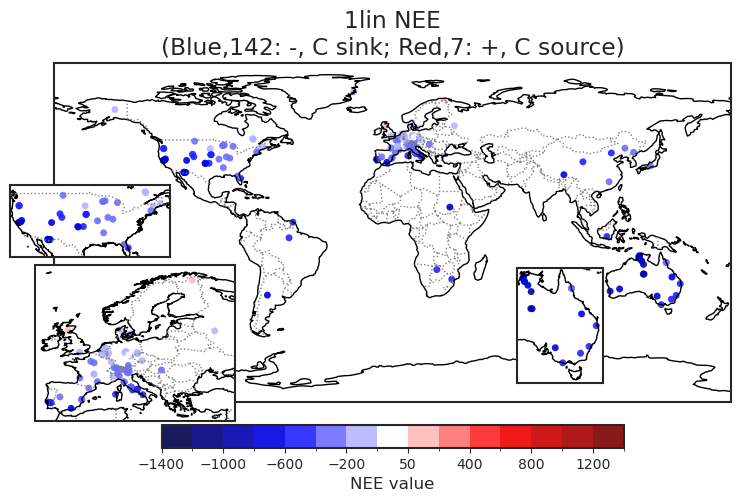

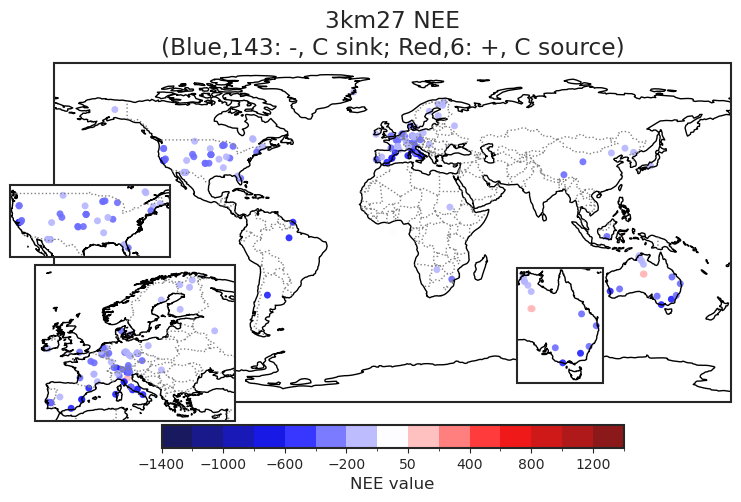

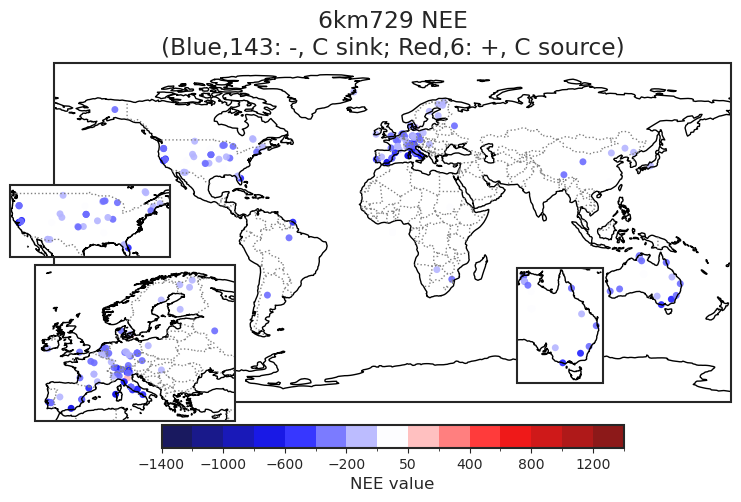

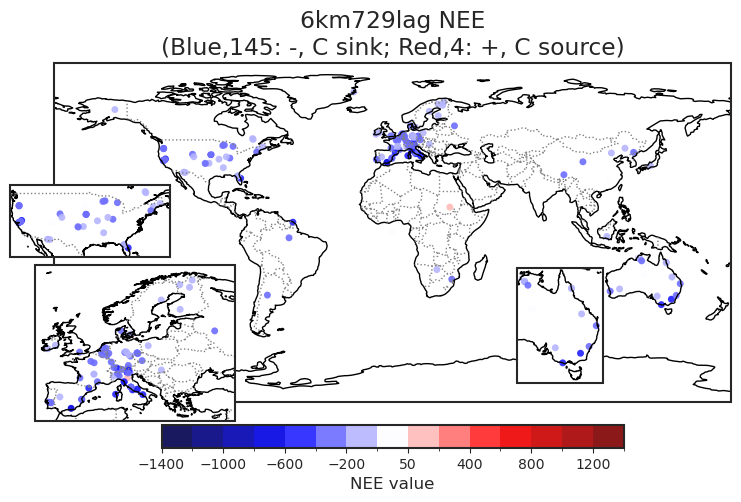

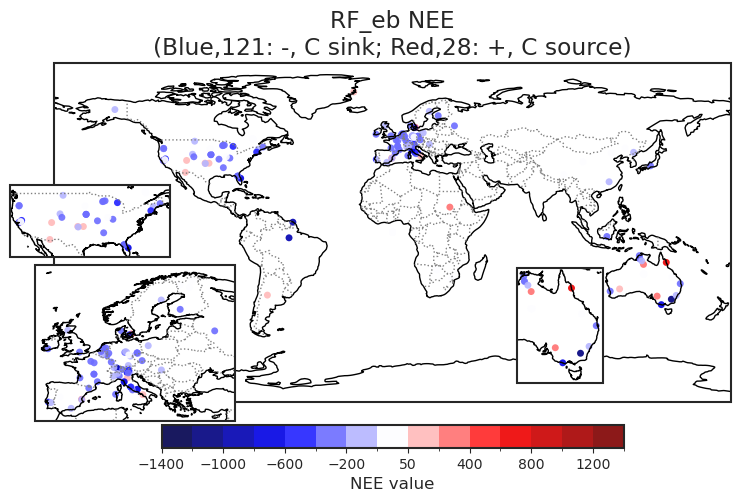

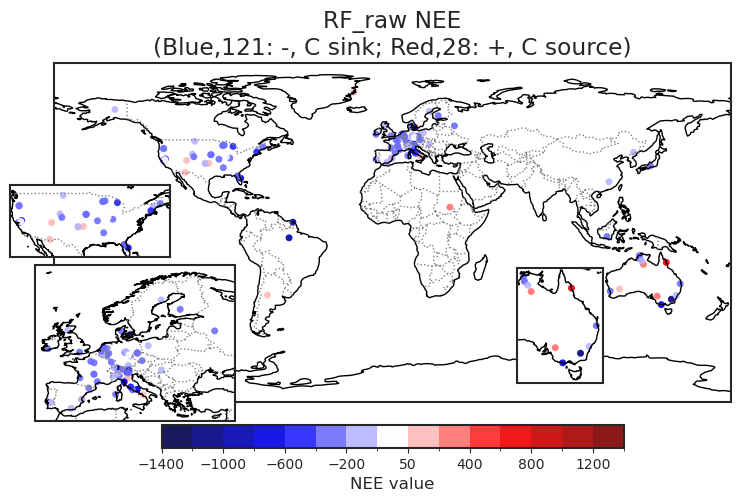

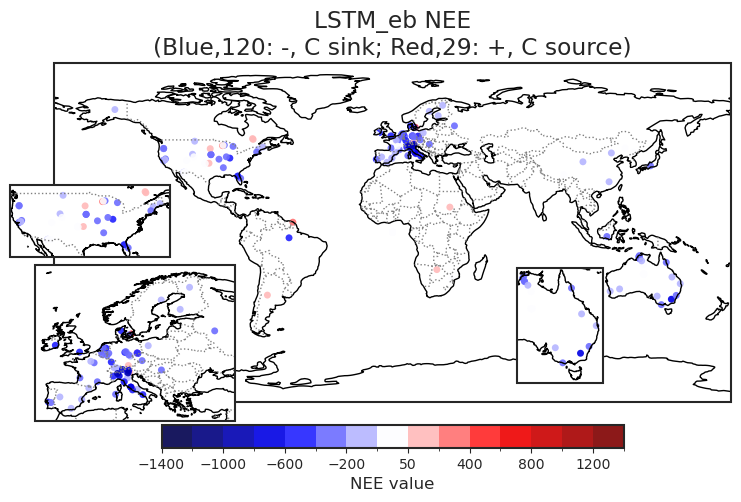

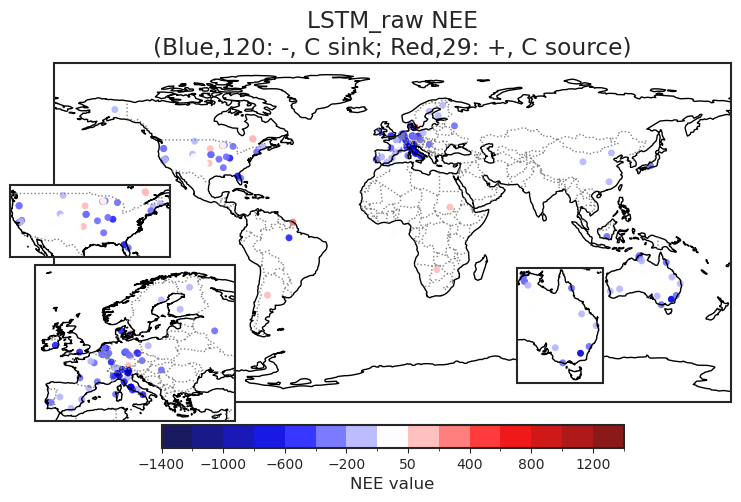

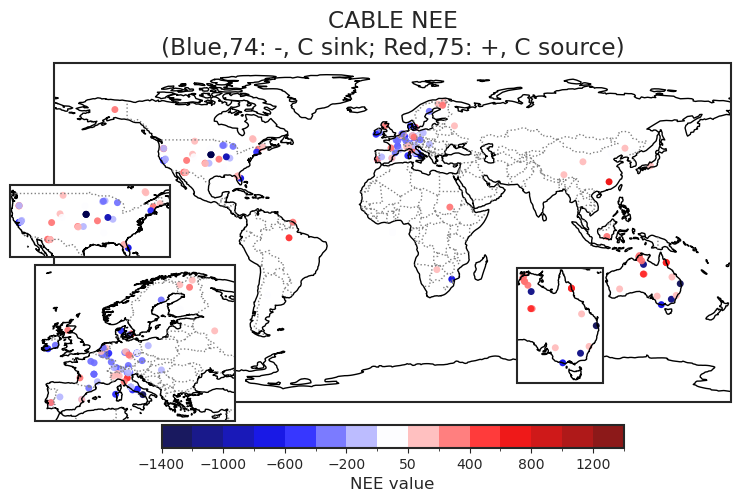

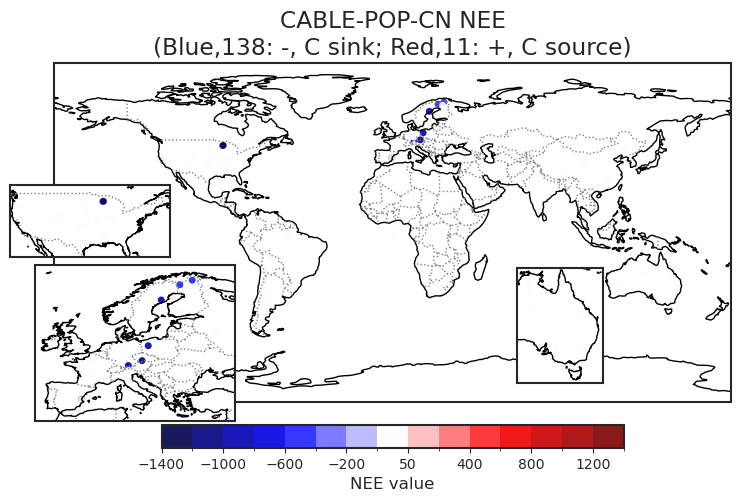

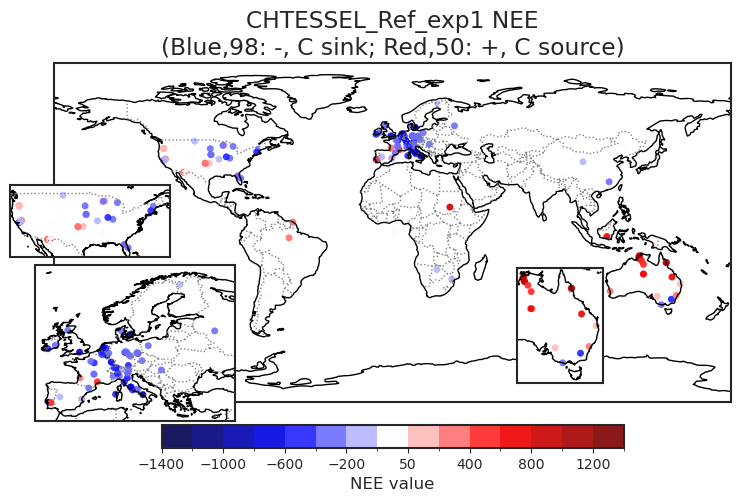

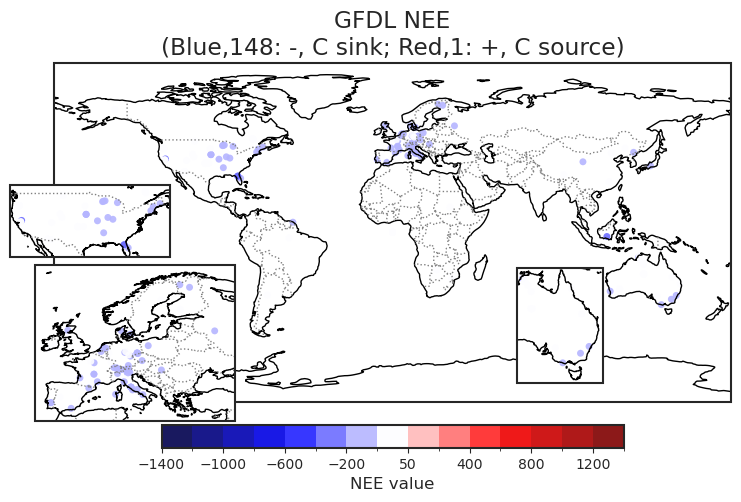

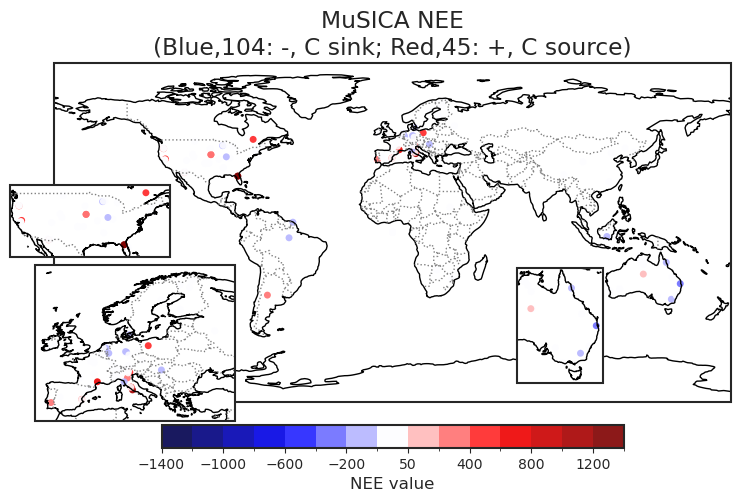

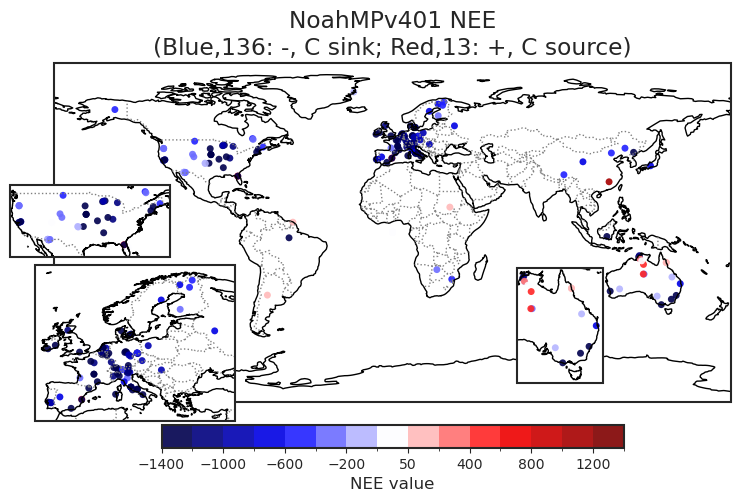

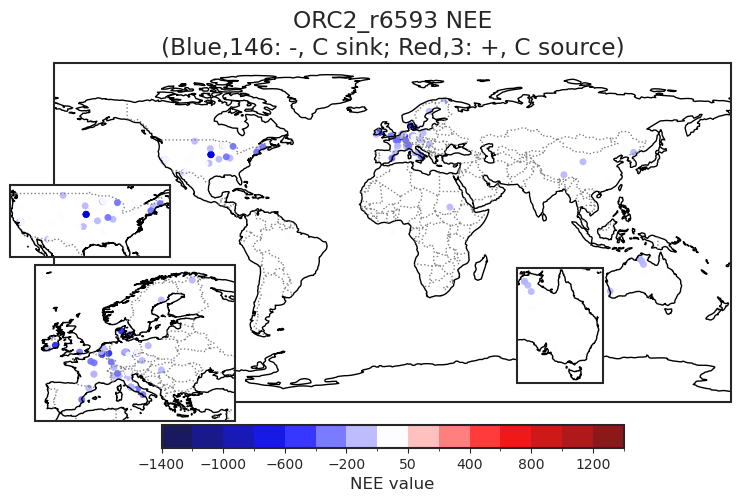

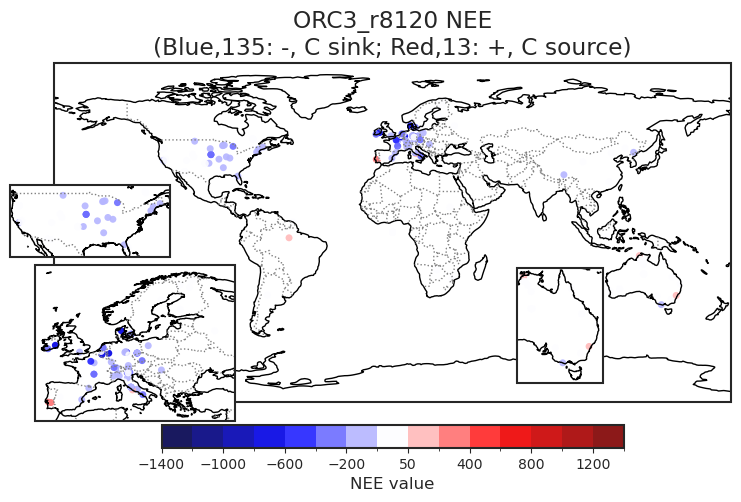

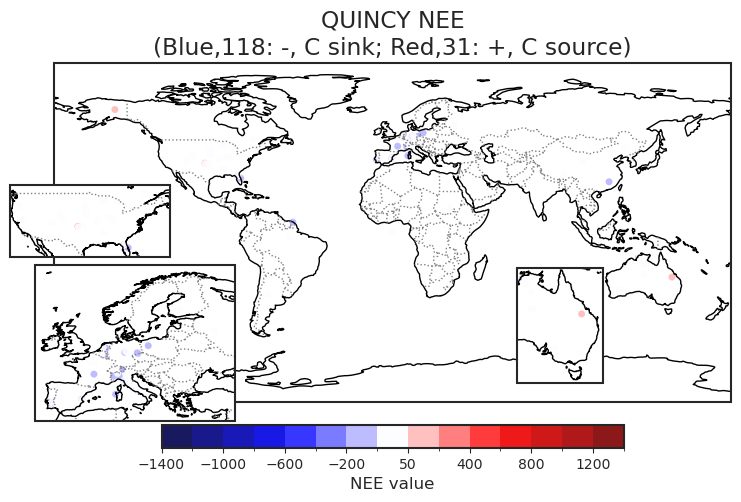

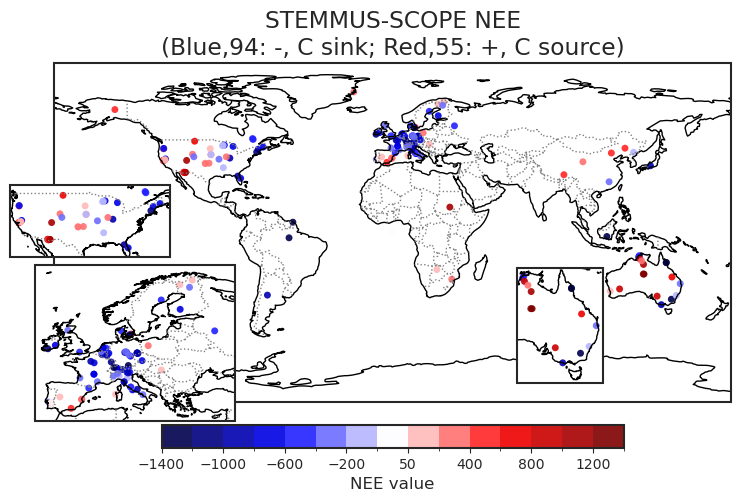

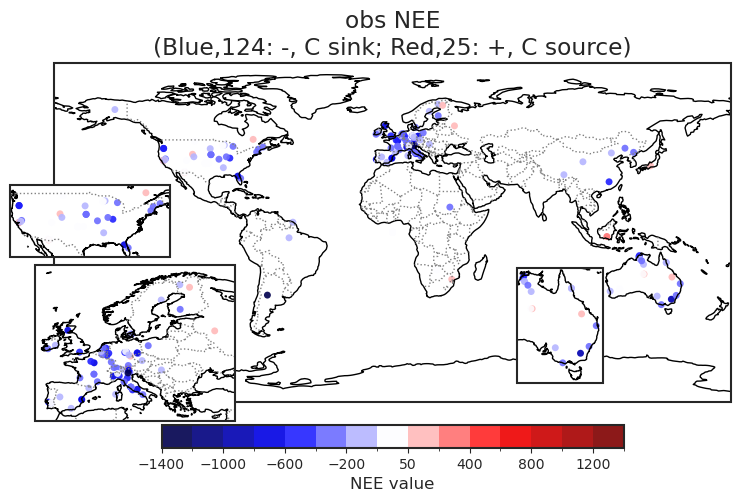

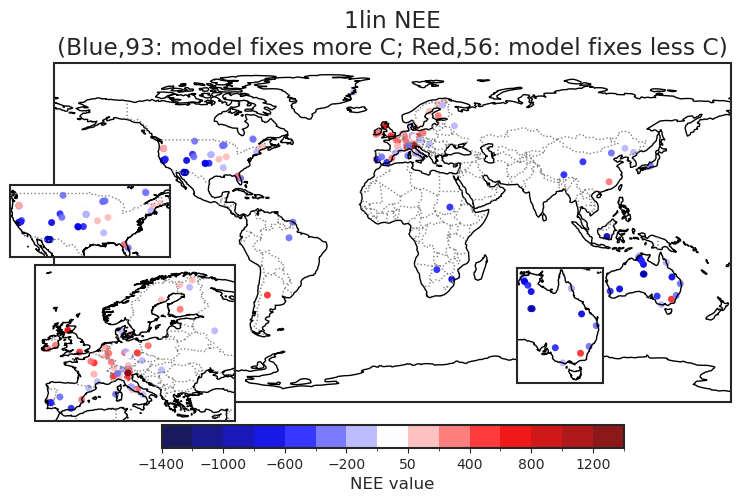

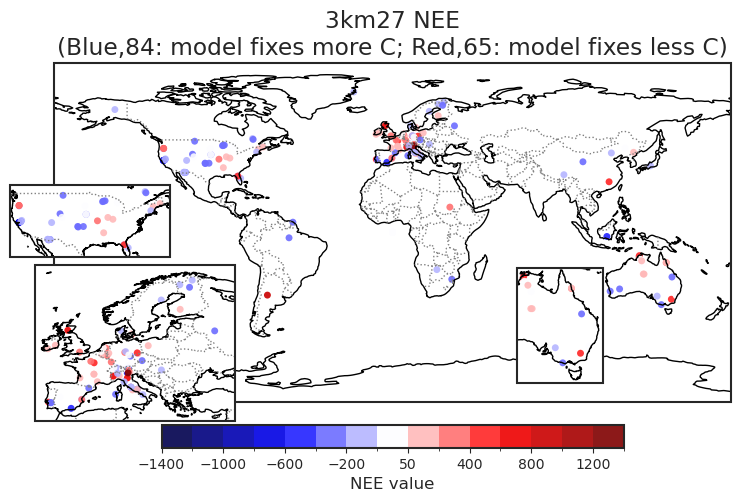

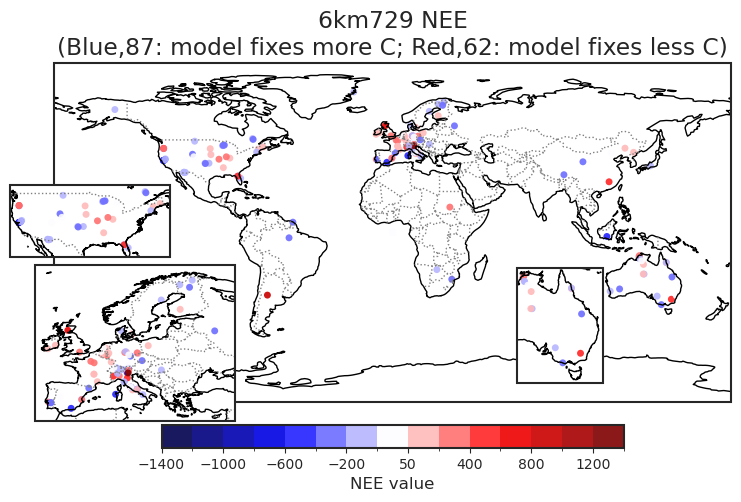

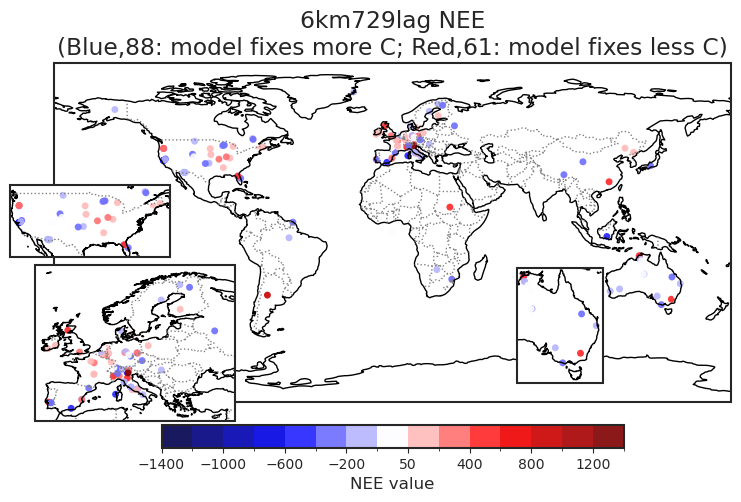

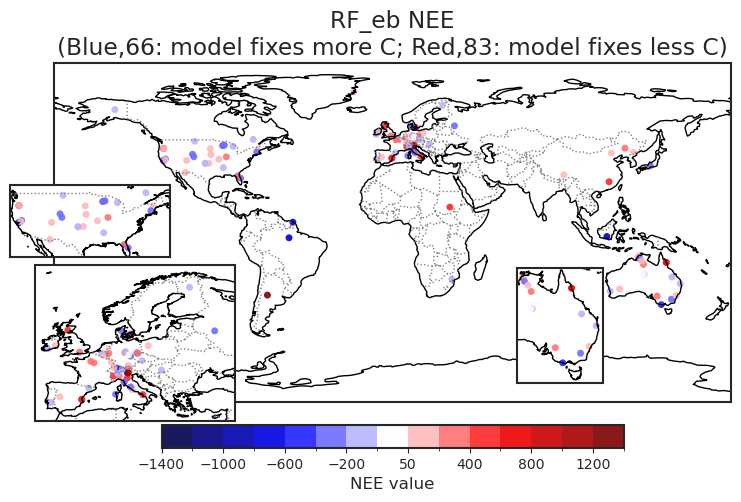

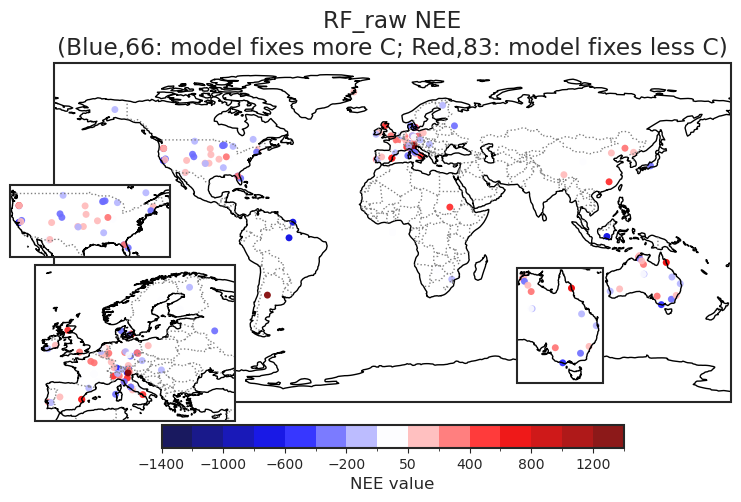

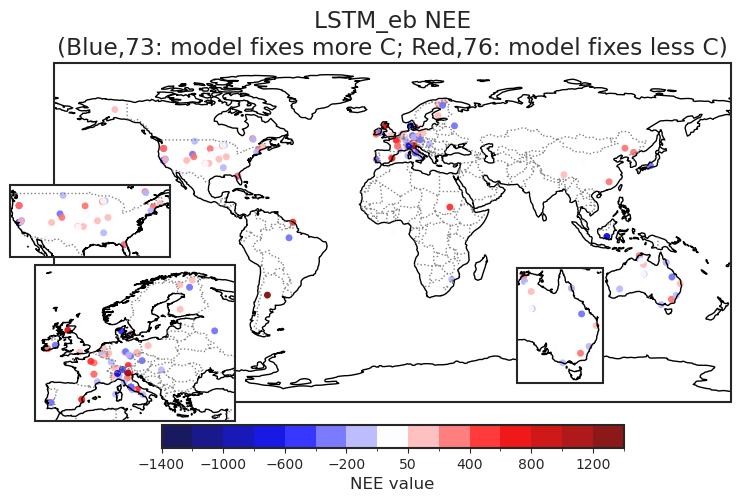

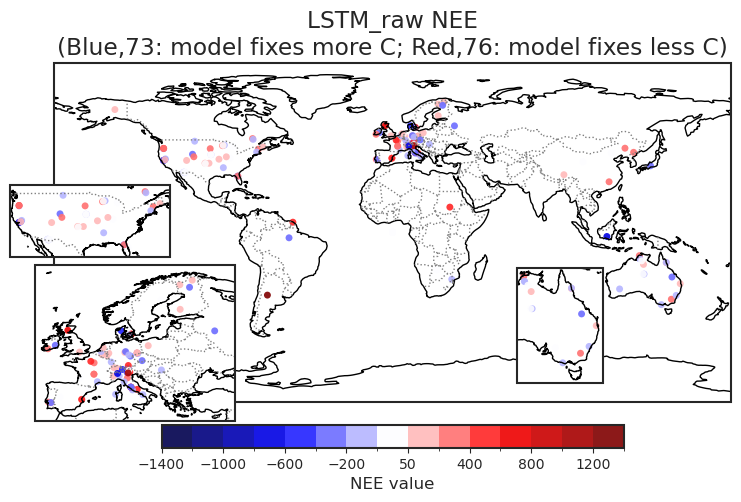

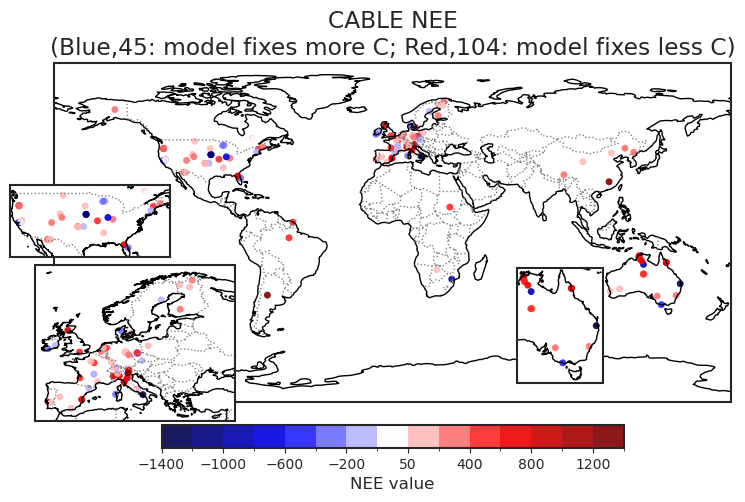

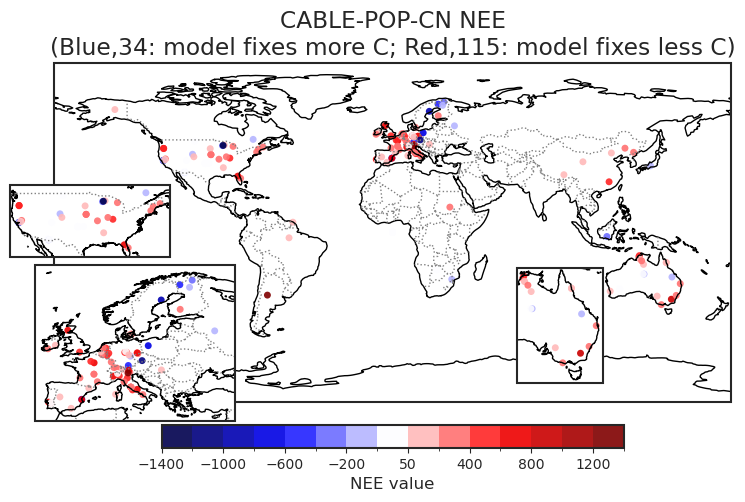

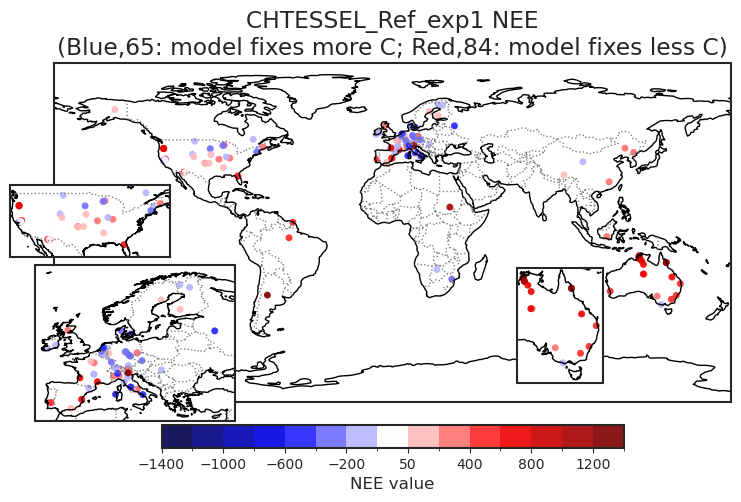

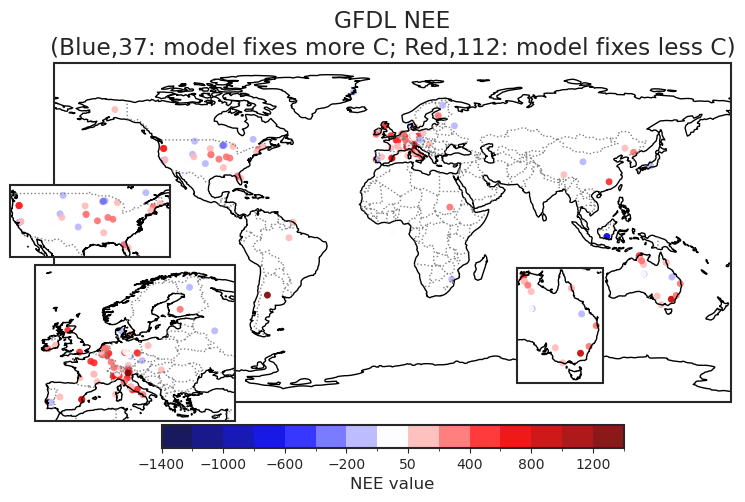

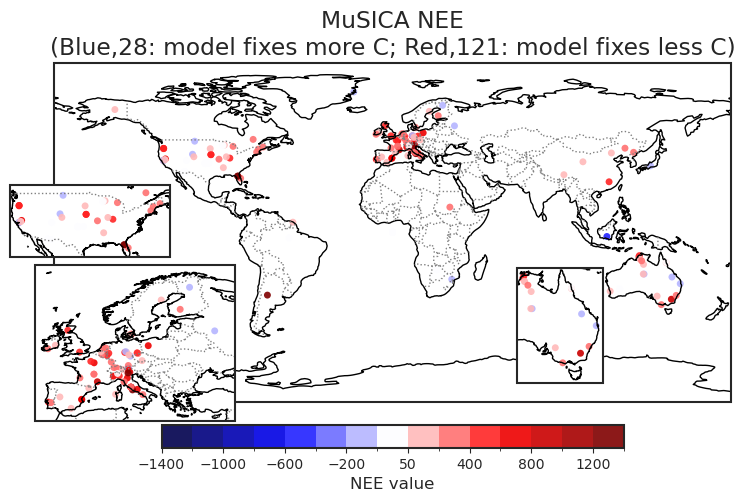

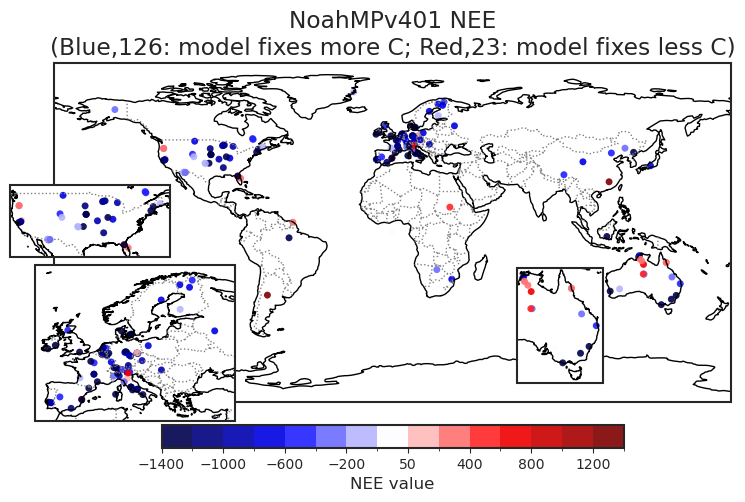

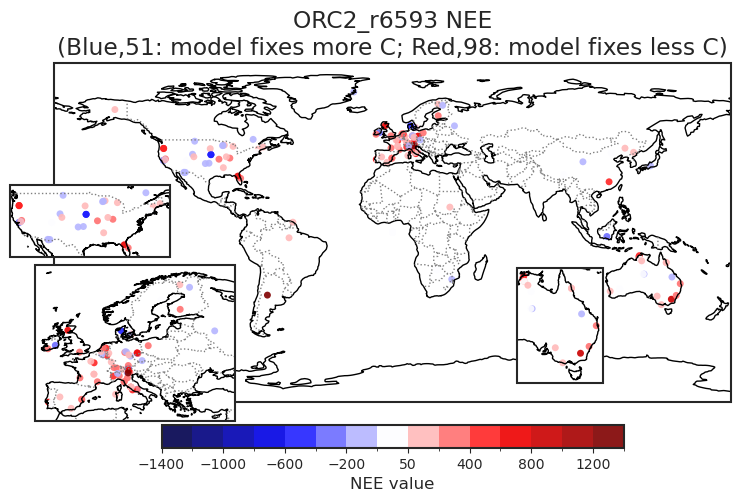

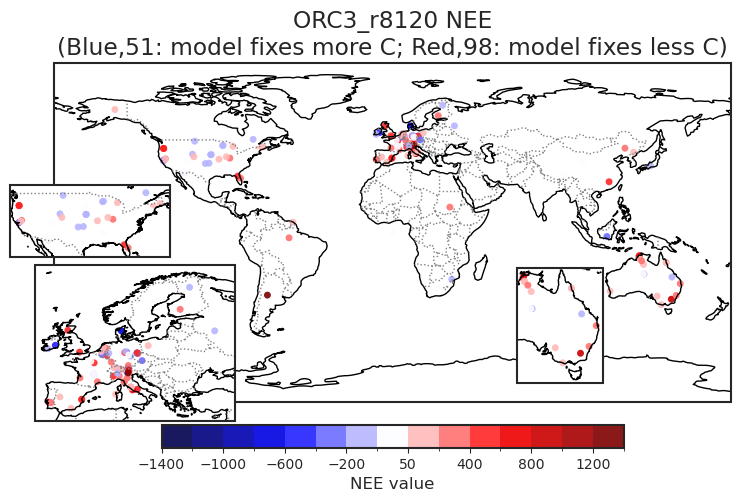

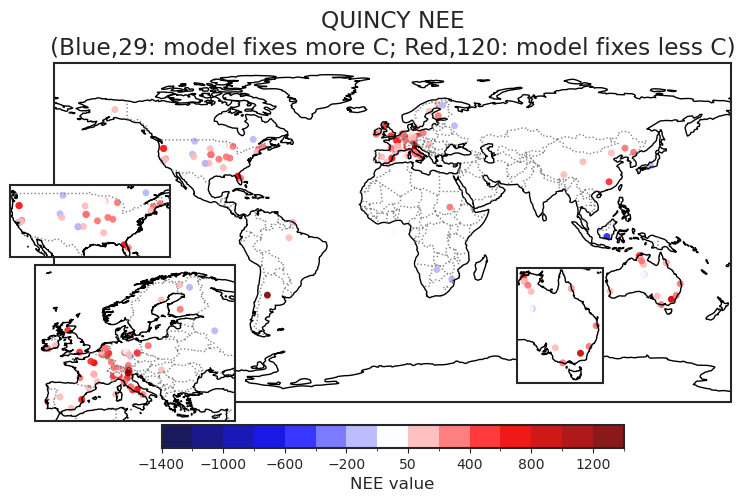

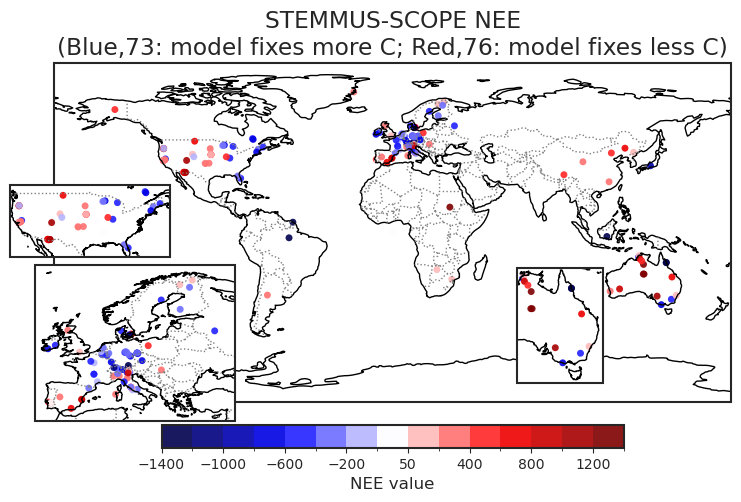

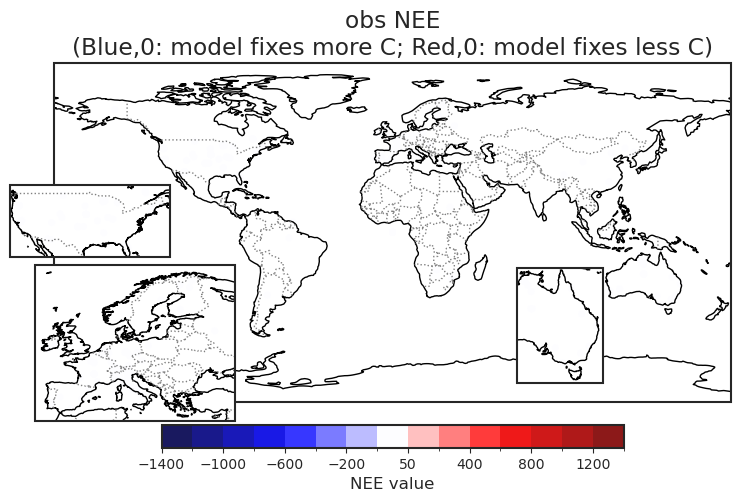

In [ ]:
var_names          = ['RS'] # 'NEE','RS','GPP'

diff               = False
PLUMBER2_path_site = "/srv/ccrc/LandAP/z5218916/script/PLUMBER2/LSM_GPP_PLUMBER2/nc_files/AR-SLu.nc"
f                  = nc.Dataset(PLUMBER2_path_site, mode='r')
for var_name in var_names:
    if var_name == 'RS' or var_name == '-GPP':
        model_list     = f.variables['GPP_models'][:]
    else:
        model_list     = f.variables[f'{var_name}_models'][:]

    model_list         = model_list.tolist()
    model_list.append('obs')

    for model_in in model_list:
        print(model_in)
        plot_annual_mean(var_name, model_in, per_LAI=False, diff=diff)
        
diff               = True
PLUMBER2_path_site = "/srv/ccrc/LandAP/z5218916/script/PLUMBER2/LSM_GPP_PLUMBER2/nc_files/AR-SLu.nc"
f                  = nc.Dataset(PLUMBER2_path_site, mode='r')
for var_name in var_names:
    if var_name == 'RS' or var_name == '-GPP':
        model_list     = f.variables['GPP_models'][:]
    else:
        model_list     = f.variables[f'{var_name}_models'][:]

    model_list         = model_list.tolist()
    model_list.append('obs')

    for model_in in model_list:
        print(model_in)
        plot_annual_mean(var_name, model_in, per_LAI=False, diff=diff)


<h5 style="color:orange;">Plot Standard Deviation of modelled annual mean</h5>  

In [ ]:
def plot_standard_deviation_in_modelled_annual_mean(var_name, model_list, per_LAI=False, diff=False, percent=False):

    for i, model_in in enumerate(model_list): 
        if i == 0:
            df_tmp    = pd.read_csv(f'./txt/{var_name}_annual_mean/{var_name}_annual_mean_{model_in}.csv')
            df_sorted = df_tmp.sort_values(by='site_name')
            df        = df_sorted
            df.rename(columns={var_name: f'{model_in}_{var_name}'}, inplace=True)
        else:
            df_tmp                       = pd.read_csv(f'./txt/{var_name}_annual_mean/{var_name}_annual_mean_{model_in}.csv')
            df_sorted                    = df_tmp.sort_values(by='site_name')
            df[f'{model_in}_{var_name}'] = df_sorted[var_name]

    # Calculate Standard Deviation for each site for all variables with the name pattern
    std_columns = [f'{model_in}_{var_name}' for model_in in model_list if f'{model_in}_{var_name}' in df.columns]
    # print(df[std_columns])

    df['std_dev'] = df[std_columns].apply(lambda row: row.std(), axis=1) # calcuate sample standard deviation (subtract one degree of freedom). Same as np.std(row_values, ddof=1)
    print(np.min(df['std_dev']),np.max(df['std_dev']),)
    lat           = df['lat']
    lon           = df['lon']
    
    if percent:
        df_obs        = pd.read_csv(f'./txt/{var_name}_annual_mean/{var_name}_annual_mean_obs.csv')
        df_obs_sorted = df_obs.sort_values(by='site_name')
        df['std_dev_per'] = np.where(df_obs_sorted[var_name] != 0, df['std_dev']/df_obs_sorted[var_name], np.nan)

    if var_name == 'NEE':
        marker_scale      = 1
    elif var_name == 'GPP':
        marker_scale      = 1

    cmap = plt.cm.jet #BrBG

    # Map the normalized values to RGBA colors
    if percent:
        norm = plt.Normalize(vmin=0, vmax=0.3)
        colors = cmap(norm(df['std_dev_per']))
    else:
        norm = plt.Normalize(vmin=0, vmax=1000)
        colors = cmap(norm(df['std_dev']))
    
    # Define marker size based on the absolute value of NEE (scaled for better visibility)
    marker_size = np.abs(df['std_dev'])*marker_scale  # Adjust scaling factor (100) as necessary for your data
    
    # Create a global map plot
    fig = plt.figure(figsize=(10, 5))
    ax  = plt.axes(projection=ccrs.PlateCarree())

    plt.rcParams['text.usetex']     = False
    plt.rcParams['font.family']     = "sans-serif"
    plt.rcParams['font.serif']      = "Helvetica"
    plt.rcParams['axes.linewidth']  = 1.5
    plt.rcParams['axes.labelsize']  = 14
    plt.rcParams['font.size']       = 14
    plt.rcParams['legend.fontsize'] = 10
    plt.rcParams['xtick.labelsize'] = 14
    plt.rcParams['ytick.labelsize'] = 14

    almost_black = '#262626'
    # change the tick colors also to the almost black
    plt.rcParams['ytick.color']     = almost_black
    plt.rcParams['xtick.color']     = almost_black

    # change the text colors also to the almost black
    plt.rcParams['text.color']      = almost_black

    # Change the default axis colors from black to a slightly lighter black,
    # and a little thinner (0.5 instead of 1)
    plt.rcParams['axes.edgecolor']  = almost_black
    plt.rcParams['axes.labelcolor'] = almost_black

    # set the box type of sequence number
    props = dict(boxstyle="round", facecolor='white', alpha=0.0, ec='white')

    # Add coastlines and other map features
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':', color='gray')
    ax.add_feature(cfeature.LAND, facecolor='white')
    ax.add_feature(cfeature.OCEAN, facecolor="white") # edgecolor='none', 
    ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())  # [lon_min, lon_max, lat_min, lat_max]

    # Scatter plot the flux sites with colors and sizes based on NEE
    sc = ax.scatter(lon, lat, alpha=0.8, s=40, edgecolors='none', facecolors=colors, transform=ccrs.PlateCarree()) # marker_size
    cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, location='right')
    
    plt.title(f'{var_name} standard deviation among models')
    
    # Zoomed-in plot for Europe
    ax_europe = plt.axes([0.1, 0.1, 0.2, 0.4], projection=ccrs.PlateCarree())  # Adjust position and size as needed
    ax_europe.set_extent([-12, 40, 34, 73], crs=ccrs.PlateCarree())  # Europe coordinates

    # Add coastlines and features for the zoomed plot
    ax_europe.coastlines()
    ax_europe.add_feature(cfeature.BORDERS, linestyle=':', color='gray')
    ax_europe.add_feature(cfeature.LAND, facecolor='white')
    ax_europe.add_feature(cfeature.OCEAN, facecolor="white") # edgecolor='none', 
    
    # Scatter plot the flux sites for the Europe zoomed-in plot
    sc_europe = ax_europe.scatter(lon, lat, alpha=0.8, s=40, edgecolors='none', facecolors=colors, transform=ccrs.PlateCarree())
    
    # Get the directory path
    directory = f'./plots/Global_map_annual_mean_{var_name}'
    # Create the directory if it doesn't exist
    if not os.path.exists(directory):
        os.makedirs(directory, exist_ok=True)
    plt.savefig(f'{directory}/Global_map_std_among_models_{var_name}.png',dpi=300)
        
    return

In [ ]:
var_name           = 'GPP'    

PLUMBER2_path_site = "/srv/ccrc/LandAP/z5218916/script/PLUMBER2/LSM_GPP_PLUMBER2/nc_files/AR-SLu.nc"
f                  = nc.Dataset(PLUMBER2_path_site, mode='r')
model_list         = f.variables[f'{var_name}_models'][:]
model_list         = model_list.tolist()
# model_list.append('obs')
plot_standard_deviation_in_modelled_annual_mean(var_name, model_list)

In [ ]:
var_name           = 'NEE'    

PLUMBER2_path_site = "/srv/ccrc/LandAP/z5218916/script/PLUMBER2/LSM_GPP_PLUMBER2/nc_files/AR-SLu.nc"
f                  = nc.Dataset(PLUMBER2_path_site, mode='r')
model_list         = f.variables[f'{var_name}_models'][:]
model_list         = model_list.tolist()
# model_list.append('obs')
plot_standard_deviation_in_modelled_annual_mean(var_name, model_list)

<h5 style="color:orange;">Plot montly mean</h5>  

In [ ]:
def plot_monthly_mean(var_name, model_in, month=0, per_LAI=False, diff=False):
    
    if var_name == 'RS':
        try:
            if per_LAI:
                df_NEE_tmp  = pd.read_csv(f'./txt/NEE_monthly_mean_per_LAI/NEE_month{month}_mean_per_LAI_{model_in}.csv')
                df_GPP_tmp  = pd.read_csv(f'./txt/GPP_monthly_mean_per_LAI/GPP_month{month}_mean_per_LAI_{model_in}.csv')
            else:
                df_NEE_tmp  = pd.read_csv(f'./txt/NEE_monthly_mean/NEE_month{month}_mean_{model_in}.csv')
                df_GPP_tmp  = pd.read_csv(f'./txt/GPP_monthly_mean/GPP_month{month}_mean_{model_in}.csv')

            df_NEE  = df_NEE_tmp.sort_values(by='site_name')
            df_GPP  = df_GPP_tmp.sort_values(by='site_name')

            var     = df_NEE['NEE'].values+df_GPP['GPP'].values
            lat     = df_NEE['lat']
            lon     = df_NEE['lon']

            RS_GPP_r,  RS_GPP_p  = pearsonr(var, df_GPP['GPP'].values)
            RS_NEE_r,  RS_NEE_p  = pearsonr(var, df_NEE['NEE'].values)
            GPP_NEE_r, GPP_NEE_p = pearsonr(df_GPP['GPP'].values, df_NEE['NEE'].values)

        except:
            return
        
    elif var_name == '-GPP':
        if per_LAI:
            df  = pd.read_csv(f'./txt/GPP_monthly_mean_per_LAI/GPP_month{month}_mean_per_LAI_{model_in}.csv')
        else:
            df  = pd.read_csv(f'./txt/GPP_monthly_mean/GPP_month{month}_mean_{model_in}.csv')
        var     = df['GPP']*(-1)
        lat     = df['lat']
        lon     = df['lon']  
        
    else:
        if per_LAI:
            df  = pd.read_csv(f'./txt/{var_name}_monthly_mean_per_LAI/{var_name}_month{month}_mean_per_LAI_{model_in}.csv')
        else:
            df  = pd.read_csv(f'./txt/{var_name}_monthly_mean/{var_name}_month{month}_mean_{model_in}.csv')
        var     = df[var_name]
        lat     = df['lat']
        lon     = df['lon']

    # Convert NEE to a numpy array (for easier manipulation)
    var = np.array(var)
    
    if diff:
        if var_name == 'RS':
            try:
                if per_LAI:
                    df_obs_NEE_tmp  = pd.read_csv(f'./txt/NEE_monthly_mean_per_LAI/NEE_month{month}_mean_per_LAI_obs.csv')
                    df_obs_GPP_tmp  = pd.read_csv(f'./txt/GPP_monthly_mean_per_LAI/GPP_month{month}_mean_per_LAI_obs.csv')
                else:
                    df_obs_NEE_tmp  = pd.read_csv(f'./txt/NEE_monthly_mean/NEE_month{month}_mean_obs.csv')
                    df_obs_GPP_tmp  = pd.read_csv(f'./txt/GPP_monthly_mean/GPP_month{month}_mean_obs.csv')
                
                df_obs_NEE  = df_obs_NEE_tmp.sort_values(by='site_name')
                df_obs_GPP  = df_obs_GPP_tmp.sort_values(by='site_name')
                
                var_obs = df_obs_NEE['NEE'].values+df_obs_GPP['GPP'].values
                var_obs = np.array(var_obs)
            except:
                return
        elif var_name == '-GPP':
            if per_LAI:
                df_obs = pd.read_csv(f'./txt/GPP_monthly_mean_per_LAI/GPP_month{month}_mean_per_LAI_obs.csv')
            else:
                df_obs = pd.read_csv(f'./txt/GPP_monthly_mean/GPP_month{month}_mean_obs.csv')
            var_obs = df_obs['GPP']*(-1)
            var_obs = np.array(var_obs)
        else:
            if per_LAI:
                df_obs = pd.read_csv(f'./txt/{var_name}_monthly_mean_per_LAI/{var_name}_month{month}_mean_per_LAI_obs.csv')
            else:
                df_obs = pd.read_csv(f'./txt/{var_name}_monthly_mean/{var_name}_month{month}_mean_obs.csv')
            var_obs = df_obs[var_name]
            var_obs = np.array(var_obs)

    if diff:
        var_plot = var-var_obs
        if var_name == 'RS':
            NEE_diff = df_NEE['NEE'].values - df_obs_NEE['NEE'].values 
            GPP_diff = df_GPP['GPP'].values - df_obs_GPP['GPP'].values 
            RS_GPP_r,  RS_GPP_p  = pearsonr(var_plot, GPP_diff)
            RS_NEE_r,  RS_NEE_p  = pearsonr(var_plot, NEE_diff)
            GPP_NEE_r, GPP_NEE_p = pearsonr(GPP_diff, NEE_diff)
    else:
        var_plot = var
    
    # Count the number of blue and red dots
    blue_count = np.sum(var_plot < 0)
    red_count  = np.sum(var_plot > 0)
    
    # Define the color map for the values
    cmap = plt.get_cmap('seismic')  # Choose a colormap that represents the data
    # norm = mcolors.Normalize(vmin=-100, vmax=100)  # Normalize the values
    
    # Define 11 discrete levels for color mapping
    levels = [-100,-90,-80,-70,-60,-50,-40,-30,-20,-10,
              10,20,30,40,50,60,70,80,90,100]

    # Normalize the values to the 11 levels
    norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=cmap.N)
    
    # Create a global map plot
    fig = plt.figure(figsize=(10, 5))
    ax  = plt.axes(projection=ccrs.PlateCarree())

    plt.rcParams['text.usetex']     = False
    plt.rcParams['font.family']     = "sans-serif"
    plt.rcParams['font.serif']      = "Helvetica"
    plt.rcParams['axes.linewidth']  = 1.5
    plt.rcParams['axes.labelsize']  = 14
    plt.rcParams['font.size']       = 14
    plt.rcParams['legend.fontsize'] = 10
    plt.rcParams['xtick.labelsize'] = 14
    plt.rcParams['ytick.labelsize'] = 14

    almost_black = '#262626'
    # change the tick colors also to the almost black
    plt.rcParams['ytick.color']     = almost_black
    plt.rcParams['xtick.color']     = almost_black

    # change the text colors also to the almost black
    plt.rcParams['text.color']      = almost_black

    # Change the default axis colors from black to a slightly lighter black,
    # and a little thinner (0.5 instead of 1)
    plt.rcParams['axes.edgecolor']  = almost_black
    plt.rcParams['axes.labelcolor'] = almost_black

    # set the box type of sequence number
    props = dict(boxstyle="round", facecolor='white', alpha=0.0, ec='white')

    # Add coastlines and other map features
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':', color='gray')
    ax.add_feature(cfeature.LAND, facecolor='white')
    ax.add_feature(cfeature.OCEAN, facecolor="white") # edgecolor='none', 
    ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())  # [lon_min, lon_max, lat_min, lat_max]

    
    alpha = 0.9
    marker_size = 25
    
    # Scatter plot the flux sites with colors and sizes based on NEE
    sc = ax.scatter(lon, lat, alpha= alpha, c=var_plot, s=marker_size, cmap=cmap, norm=norm, edgecolors='none', facecolors=colors, transform=ccrs.PlateCarree()) # s=marker_size, 
    if var_name == 'RS':
        txt     = ax.text(0.48, 0.13, f'RS_GPP_r:{RS_GPP_r:.2f}\nRS_NEE_r:{RS_NEE_r:.2f}\nGPP_NEE_r:{GPP_NEE_r:.2f}', fontsize=9, color='black',transform=ax.transAxes)        
        
    # Set title and show the plot
    if diff:
        message       = '_diff'
        if var_name == 'NEE':
            title_message = f'(Blue,{blue_count}: model fixes more C; Red,{red_count}: model fixes less C)'
        elif var_name == 'GPP':
            title_message = f'(Blue,{blue_count}: model fixes less C; Red,{red_count}: model fixes more C)'
        elif var_name == '-GPP':
            title_message = f'(Blue,{blue_count}: model fixes more C; Red,{red_count}: model fixes less C)'
        elif var_name == 'RS':
            title_message = f'(Blue,{blue_count}: model loses less C; Red,{red_count}: model loses more C)'
            
    else:
        message       = ''
        
        if var_name == 'NEE':
            title_message = f'(Blue,{blue_count}: -, C sink; Red,{red_count}: +, C source)'
        elif var_name == 'GPP':
            title_message = f'(Blue,{blue_count}: -, C source; Red,{red_count}: +, C sink)'
        elif var_name == '-GPP':
            title_message = f'(Blue,{blue_count}: -, C sink; Red,{red_count}: +, C source)'
        elif var_name == 'RS':
            title_message = f'(Blue,{blue_count}: -, C sink; Red,{red_count}: +, C source)'
            
    plt.title(f'{model_in} {var_name}\n{title_message}')
    cbar = plt.colorbar(sc, ax=ax, orientation='horizontal',  fraction=0.06,  pad=0.06) # 
    cbar.ax.tick_params(labelsize=10)
    cbar.set_label(f'{var_name} value', fontsize=12)


    # ========= Zoomed-in plot for US =========
    ax_us = plt.axes([0.13, 0.4, 0.16, 0.325], projection=ccrs.PlateCarree())  # Adjust position and size as needed
    ax_us.set_extent([-125,-65,25,52], crs=ccrs.PlateCarree())  # Europe coordinates

    # Add coastlines and features for the zoomed plot
    ax_us.coastlines()
    ax_us.add_feature(cfeature.BORDERS, linestyle=':', color='gray')
    ax_us.add_feature(cfeature.LAND, facecolor='white')
    ax_us.add_feature(cfeature.OCEAN, facecolor="white") # edgecolor='none', 
    
    # Scatter plot the flux sites for the Europe zoomed-in plot
    sc_us = ax_us.scatter(lon, lat, alpha=alpha, s=marker_size, c=var_plot, cmap=cmap, norm=norm, edgecolors='none', facecolors=colors, transform=ccrs.PlateCarree()) # s=marker_size,
    
        
    # ========= Zoomed-in plot for Europe =========
    ax_europe = plt.axes([0.155, 0.12, 0.20, 0.4], projection=ccrs.PlateCarree())  # Adjust position and size as needed
    ax_europe.set_extent([-12, 38, 34, 73], crs=ccrs.PlateCarree())  # Europe coordinates

    # Add coastlines and features for the zoomed plot
    ax_europe.coastlines()
    ax_europe.add_feature(cfeature.BORDERS, linestyle=':', color='gray')
    ax_europe.add_feature(cfeature.LAND, facecolor='white')
    ax_europe.add_feature(cfeature.OCEAN, facecolor="white") # edgecolor='none', 
    
    # Scatter plot the flux sites for the Europe zoomed-in plot
    sc_europe = ax_europe.scatter(lon, lat, alpha=alpha, s=marker_size, c=var_plot, cmap=cmap, norm=norm, edgecolors='none', facecolors=colors, transform=ccrs.PlateCarree()) # s=marker_size, 
    
    
    # ========= Zoomed-in plot for Australia =========
    ax_au = plt.axes([0.63, 0.24, 0.1, 0.23], projection=ccrs.PlateCarree())  # Adjust position and size as needed
    ax_au.set_extent([129,155,-44.5,-10], crs=ccrs.PlateCarree())  # Europe coordinates

    # Add coastlines and features for the zoomed plot
    ax_au.coastlines()
    ax_au.add_feature(cfeature.BORDERS, linestyle=':', color='gray')
    ax_au.add_feature(cfeature.LAND, facecolor='white')
    ax_au.add_feature(cfeature.OCEAN, facecolor="white") # edgecolor='none', 
    
    # Scatter plot the flux sites for the Europe zoomed-in plot
    sc_au = ax_au.scatter(lon, lat, alpha=alpha, s=marker_size, c=var_plot, cmap=cmap, norm=norm, edgecolors='none', facecolors=colors, transform=ccrs.PlateCarree()) # s=marker_size, 
    
    if per_LAI:
        # Get the directory path
        directory = f'./plots/Global_map_monthly/Global_map_month{month}_mean_{var_name}_per_LAI'
        # Create the directory if it doesn't exist
        if not os.path.exists(directory):
            os.makedirs(directory, exist_ok=True)
        plt.savefig(f'{directory}/Global_map_{var_name}_per_LAI_{model_in}{message}.png',dpi=100)
    else:
        # Get the directory path
        directory = f'./plots/Global_map_monthly/Global_map_month{month}_mean_{var_name}'
        # Create the directory if it doesn't exist
        if not os.path.exists(directory):
            os.makedirs(directory, exist_ok=True)
        plt.savefig(f'{directory}/Global_map_{var_name}_{model_in}{message}.png',dpi=100)
        
    return

In [ ]:
PLUMBER2_path_site = "/srv/ccrc/LandAP/z5218916/script/PLUMBER2/LSM_GPP_PLUMBER2/nc_files/AR-SLu.nc"
f                  = nc.Dataset(PLUMBER2_path_site, mode='r')

var_names          = ['RS'] # ['NEE','-GPP','RS',] # 'NEE',,'GPP'

diff               = True
for var_name in var_names:
    if var_name == 'RS' or var_name == '-GPP':
        model_list     = f.variables['GPP_models'][:]
    else:
        model_list     = f.variables[f'{var_name}_models'][:]

    model_list         = model_list.tolist()
    model_list.append('obs')

    for model_in in model_list:
        print(model_in)
        for month in np.arange(1,13):
            plot_monthly_mean(var_name, model_in, month, per_LAI=False, diff=diff)
            
diff               = False
for var_name in var_names:
    if var_name == 'RS' or var_name == '-GPP':
        model_list     = f.variables['GPP_models'][:]
    else:
        model_list     = f.variables[f'{var_name}_models'][:]

    model_list         = model_list.tolist()
    model_list.append('obs')

    for model_in in model_list:
        print(model_in)
        for month in np.arange(1,13):
            plot_monthly_mean(var_name, model_in, month, per_LAI=False, diff=diff)